In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [7]:
project_path = "/content/drive/MyDrive/Network_Intrusion_Detection_Project/data/"

train = pd.read_csv(project_path + "UNSW_NB15_training-set.csv")
test = pd.read_csv(project_path + "UNSW_NB15_testing-set.csv")

print("Training Shape:", train.shape)
print("Testing Shape:", test.shape)

Training Shape: (82332, 45)
Testing Shape: (175341, 45)


In [8]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [10]:
missing_values = train.isnull().sum()
missing_values[missing_values > 0]

,0


In [11]:
train.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [12]:
train['label'].value_counts()

,count
label,
1,45332
0,37000


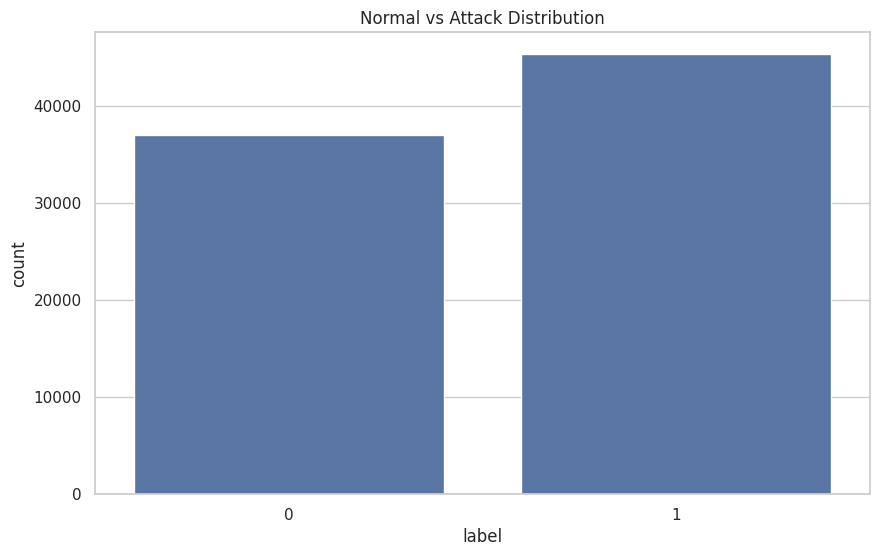

In [13]:
sns.countplot(x='label', data=train)
plt.title("Normal vs Attack Distribution")
plt.show()

In [14]:
train['attack_cat'].value_counts()

,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


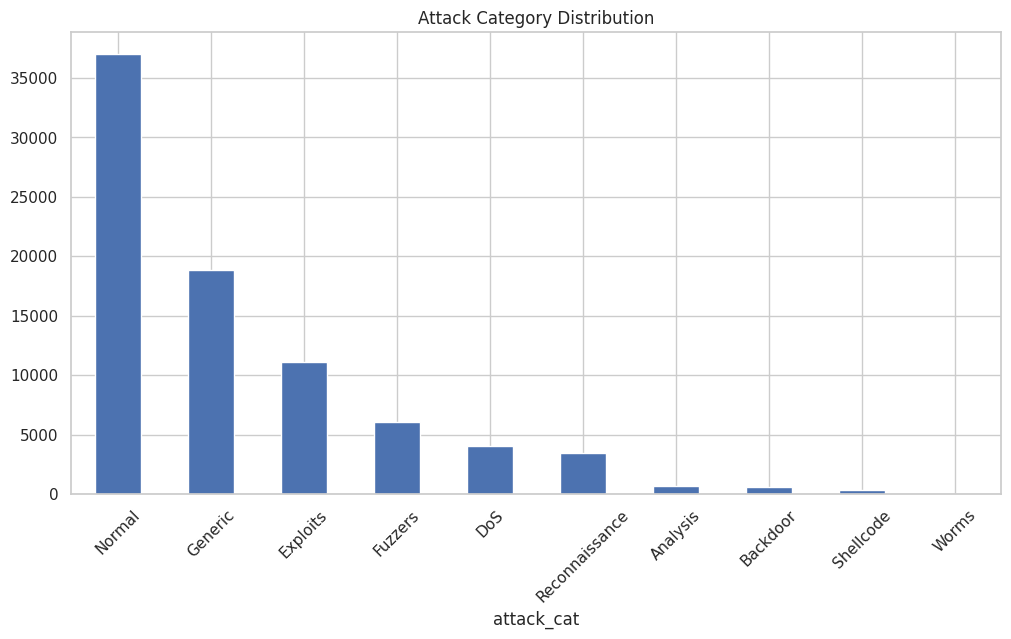

In [15]:
plt.figure(figsize=(12,6))
train['attack_cat'].value_counts().plot(kind='bar')
plt.title("Attack Category Distribution")
plt.xticks(rotation=45)
plt.show()

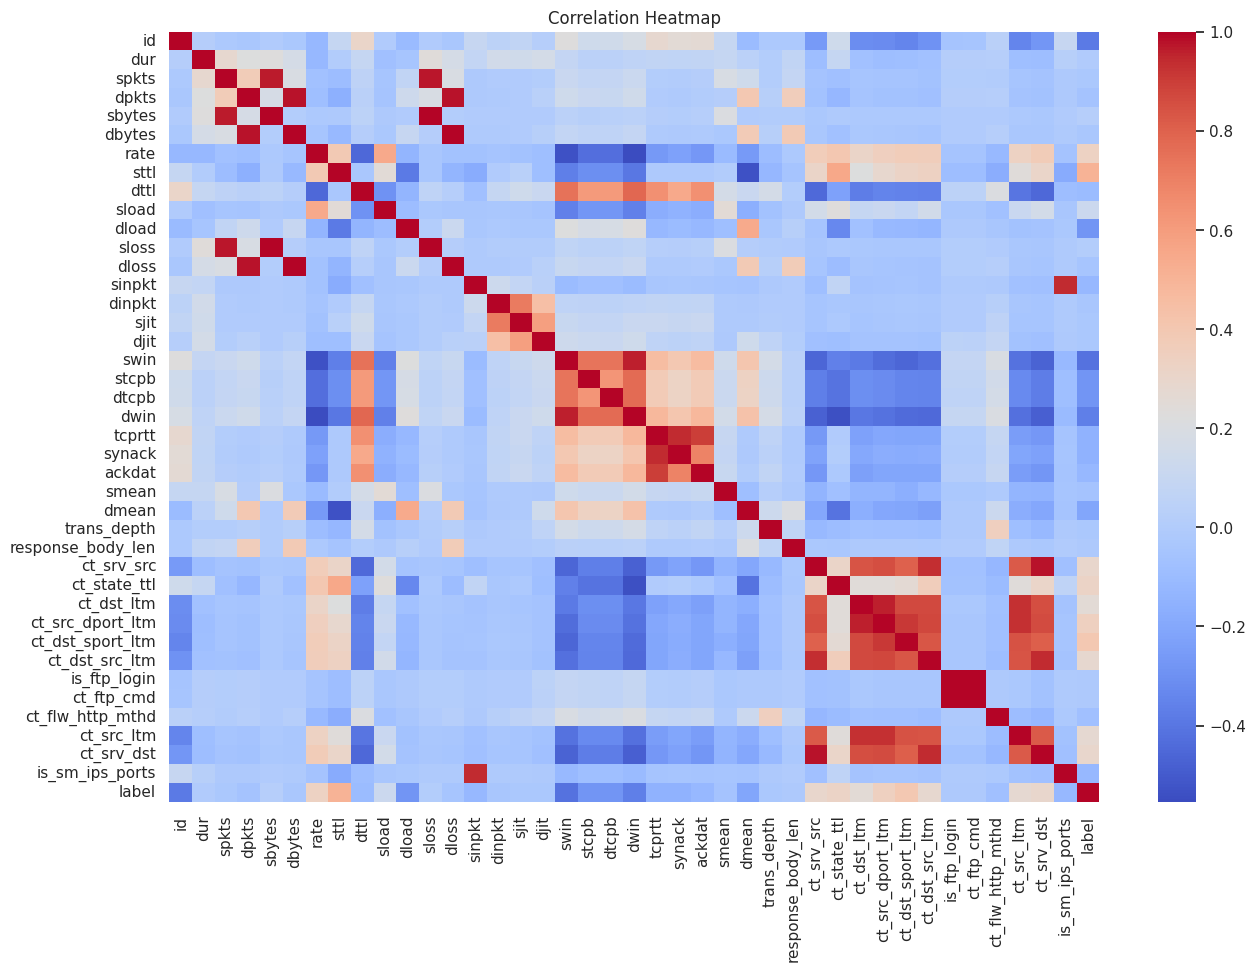

In [16]:
numeric_features = train.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))
sns.heatmap(numeric_features.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
correlation_with_target = numeric_features.corr()['label'].sort_values(ascending=False)

print("Top Positive Correlations:")
print(correlation_with_target.head(10))

print("\nTop Negative Correlations:")
print(correlation_with_target.tail(10))

Top Positive Correlations:
label               1.000000
sttl                0.504159
ct_dst_sport_ltm    0.393668
ct_src_dport_ltm    0.341513
rate                0.328629
ct_state_ttl        0.318517
ct_srv_dst          0.292931
ct_srv_src          0.290195
ct_dst_src_ltm      0.279989
ct_src_ltm          0.276494
Name: label, dtype: float64

Top Negative Correlations:
sinpkt   -0.120768
tcprtt   -0.148800
synack   -0.149944
dmean    -0.211544
dload    -0.280534
stcpb    -0.281428
dtcpb    -0.282860
dwin     -0.369257
id       -0.387489
swin     -0.414504
Name: label, dtype: float64


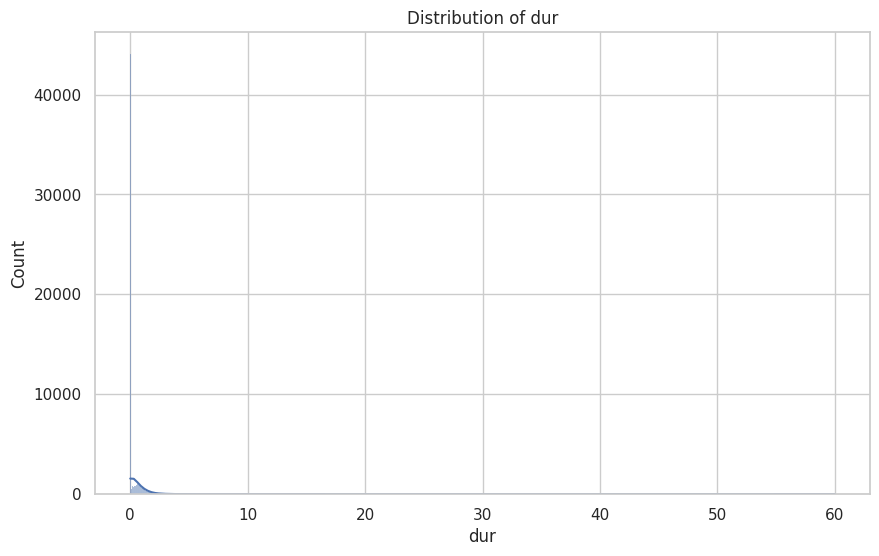

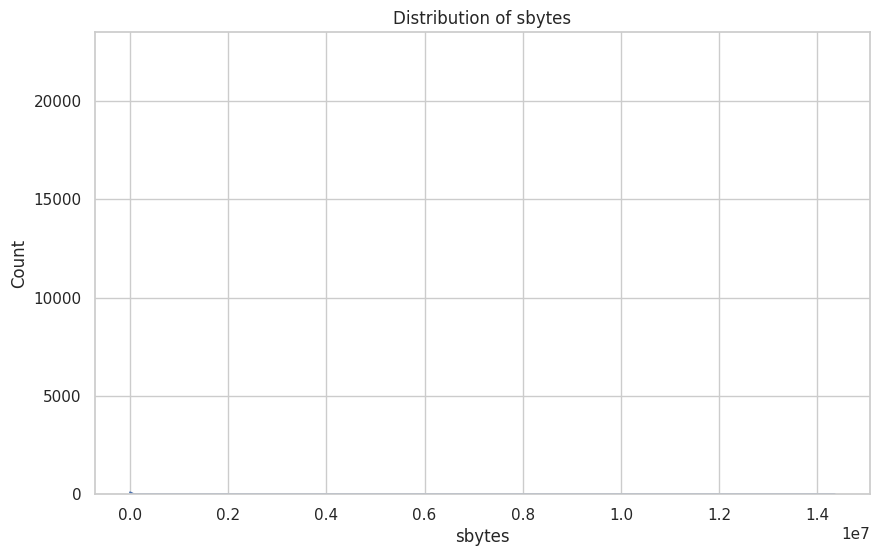

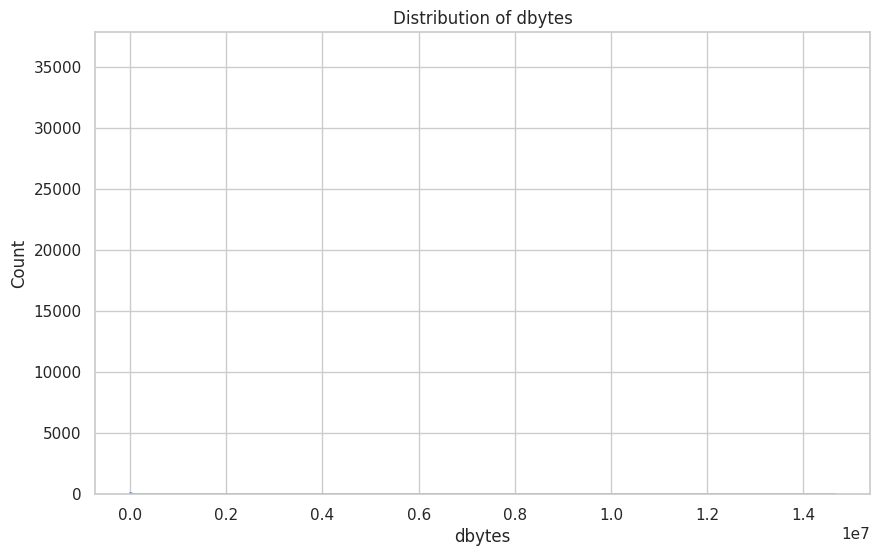

In [18]:
important_features = ['dur', 'sbytes', 'dbytes']

for feature in important_features:
    sns.histplot(train[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

In [20]:
label_counts = train['label'].value_counts(normalize=True) * 100
print(label_counts)

label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


In [21]:
train.to_csv(project_path + "train_raw_copy.csv", index=False)